# **REDES NEURONALES - PYTORCH**
**Apellido y nombre:** Vasquez Caiza Juan Marcelo.

**Carrera:** Ingenieria de Sistemas.

Haremos uso del dataset del laboratorio 4 (ONE vs ALL) para implementar una red neuronal con el uso de pytorch, para mejorar el porcentaje de precision.

In [85]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **LIBRERIAS**

Importamos torch para construir y entrenar la red neuronal y haremos uso de sklearn.preprocesing que proporciona una amplia gama de funciones y clases para preparar o preprocesar datos para modelos.

In [86]:
import torch
from sklearn.preprocessing import StandardScaler


import os

import numpy as np

from matplotlib import pyplot as plt

from scipy import optimize

import pandas as pd

%matplotlib inline

La verificacion de datos sera igual que el anterior laboratorio.

In [87]:
data = pd.read_csv('/content/drive/MyDrive/Inteligencia Artificial I/Datasets Trabajos/diabetes_012_health_indicators_BRFSS2021.csv', delimiter=',')
print('INFORMACION DE TIPO DE DATOS')
data.info()
print('\nDATOS VACIOS')
print(pd.isnull(data).sum())

INFORMACION DE TIPO DE DATOS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236378 entries, 0 to 236377
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          236378 non-null  float64
 1   HighBP                236378 non-null  int64  
 2   HighChol              236378 non-null  float64
 3   CholCheck             236378 non-null  int64  
 4   BMI                   236378 non-null  float64
 5   Smoker                236378 non-null  float64
 6   Stroke                236378 non-null  float64
 7   HeartDiseaseorAttack  236378 non-null  float64
 8   PhysActivity          236378 non-null  int64  
 9   Fruits                236378 non-null  int64  
 10  Veggies               236378 non-null  int64  
 11  HvyAlcoholConsump     236378 non-null  int64  
 12  AnyHealthcare         236378 non-null  int64  
 13  NoDocbcCost           236378 non-null  float64
 14  GenHlth               2

In [88]:
y =  data['Diabetes_012']
X = data.drop('Diabetes_012', axis=1)

print(f'Dimensiones de X (variables predictoras): {X.shape}')
print(f'Dimensiones de y (variable objetivo): {y.shape}')

Dimensiones de X (variables predictoras): (236378, 21)
Dimensiones de y (variable objetivo): (236378,)


# **Dividir set de datos:**

Dividimos los datos, stratify se encarga de que la distribucion de las clases y_train, y_test sea proporcional a la distribucion original en y.

In [89]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# **Normalizacion de datos**

Creamos una instancia de la clase StandarScaler.
Con el uso de la instancia transformamos la escala de X_train, fit() nos permite calcular la media y la desviacion estandar para cada columna y transform haciendo uso de lo calculado con anterioridad transforma cada valor en X_train. En el caso de X_test solamente haremos uso del transform ya que usaremos la media y desviacion estandar provenientes del X_train para que esten en la misma escala.  


In [90]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [91]:
print(X_train_scaled)

[[-0.84838086 -0.82060647  0.19523077 ...  0.96876167  0.907963
   0.45053472]
 [ 1.17871589  1.21861091  0.19523077 ...  1.27745932 -1.20457545
  -0.39084251]
 [-0.84838086 -0.82060647  0.19523077 ... -1.19212189  0.907963
  -1.23221974]
 ...
 [ 1.17871589  1.21861091  0.19523077 ...  0.35136637 -0.14830623
  -0.39084251]
 [-0.84838086 -0.82060647  0.19523077 ... -0.88342424 -0.14830623
  -2.49428558]
 [ 1.17871589 -0.82060647  0.19523077 ...  1.58615697  0.907963
   0.02984611]]


Creamos la varaiables n_entradas para verificar la cantidad de x que tenemos.

In [92]:
n_entradas = X_train_scaled.shape[1]

In [93]:
print(n_entradas)

21


# **Tensores**

Convertimos nuestros conjuntos de datos de numpy a tensores de tipo float y dicho tensor es movido al cpu(en nuestro caso estamos usando la cpu de google colab) y almacenado. Para el conjunto de datos y se le asigna long(int) ya que la funcion de CrossEntropyLoss de pytorch espera que el tensor objetivo sea un entero.

In [94]:
t_X_train = torch.from_numpy(X_train_scaled).float().to("cpu")
t_X_test = torch.from_numpy(X_test_scaled).float().to("cpu")
t_y_train = torch.from_numpy(y_train.values).long().to("cpu")
t_y_test = torch.from_numpy(y_test.values).long().to("cpu")

In [95]:
t_y_train

tensor([0, 0, 0,  ..., 0, 0, 0])

# **Construimos la Red Neuronal**

Definimos nuestra red neuronal, con una dimension de entrada = 21, el  tamaño de la capa oculta = 64 (neuronas en la capa media o oculta) y la dimension de salida = 3 ya que el problema es de clasificacion de multiples clases. La variable objetivo Diabetes_012 tiene tres posibles valores (0, 1, 2), que representan "No Diabetes", "Pre-Diabetes" y "Diabetes", respectivamente.

In [96]:
D_in, H, D_out = 21, 64, 3

model = torch.nn.Sequential(
    torch.nn.Linear(D_in, H),
    torch.nn.ReLU(),
    torch.nn.Linear(H, D_out),
)

In [97]:
outputs = model(torch.randn(600, 21))
outputs.shape

torch.Size([600, 3])

In [98]:
print(outputs[0][:])

tensor([ 0.2149, -0.3200, -0.2199], grad_fn=<SliceBackward0>)


In [99]:
model

Sequential(
  (0): Linear(in_features=21, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=3, bias=True)
)

# **Entrenamiento de la Red Construida**

Definimos las siguientes funciones:

**softmax:** Que nos permite convertir un vector de numeros reales (logits) en una distribucion de probabilidad. Softmax se usa en la capa de salida para obtener las probabilidades de cada clase. Esto hace que la salida de la red sea interpretable.

**cross_entropy:** Es una funcion de perdida que mide la diferencia entre 2 distribuciones de probabilidad, la funcion mide que tan equivocado esta el modelo de sus predicciones.Si el modelo predice la clase correcta con alta probabilidad, la pérdida será baja. Por el contrario, si predice la clase incorrecta con alta probabilidad, la pérdida será alta.

In [100]:
# función de pérdida y derivada

def softmax(x):
    return torch.exp(x) / torch.exp(x).sum(axis=-1,keepdims=True)

def cross_entropy(output, target):
    logits = output[torch.arange(len(output)), target]
    loss = - logits + torch.log(torch.sum(torch.exp(output), axis=-1))
    loss = loss.mean()
    return loss

# **BUCLE DE ENTRENAMIENTO**

El bucle es el proceso central donde la red neuronal aprende de los datos. Funciona de la siguiente manera: por cada "época" (una pasada completa por todo el conjunto de datos de entrenamiento), el modelo hace una predicción, calcula su error y ajusta sus parámetros (pesos y sesgos) para minimizar ese error.

epochs = Numero de epocas por el que vamos a entrenar nuestro modelo.

lr = Taza de aprendizaje(learning rate)

forward = El modelo  toma los datos de entrenamiento y los pasa a traves de sus capas para generar una prediccion.

loss = se usa la funcion de perdida cross_entropy para medir el error de la prediccion.

Ponemos en ceros los gradientes acumulados de las epocas anteriores.

***loss.backward():*** Este es el corazón del "backpropagation" (retropropagación). PyTorch calcula automáticamente el gradiente de la pérdida con respecto a cada uno de los parámetros del modelo (pesos y sesgos). El gradiente indica la dirección y magnitud del ajuste necesario.

Se desactiva el cálculo de gradientes para este paso, ya que no queremos que los ajustes en los pesos se consideren parte de la red.

Por último, los parámetros del modelo se actualizan.

In [101]:
epochs = 380
lr = 0.08
log_each = 10
l = []
for e in range(1, epochs + 1):

    # forward
    y_pred = model(t_X_train)

    # loss
    loss = cross_entropy(y_pred, t_y_train)
    l.append(loss.item())

    # ponemos a cero los gradientes
    model.zero_grad()

    # Backprop (calculamos todos los gradientes automáticamente)
    loss.backward()

    # update de los pesos
    with torch.no_grad():
        for param in model.parameters():
            param -= lr * param.grad

    if not e % log_each:
        print(f"Epoch {e}/{epochs} Loss {np.mean(l):.5f}")

Epoch 10/380 Loss 0.76671
Epoch 20/380 Loss 0.65550
Epoch 30/380 Loss 0.60144
Epoch 40/380 Loss 0.56858
Epoch 50/380 Loss 0.54636
Epoch 60/380 Loss 0.53032
Epoch 70/380 Loss 0.51817
Epoch 80/380 Loss 0.50866
Epoch 90/380 Loss 0.50099
Epoch 100/380 Loss 0.49467
Epoch 110/380 Loss 0.48937
Epoch 120/380 Loss 0.48486
Epoch 130/380 Loss 0.48098
Epoch 140/380 Loss 0.47759
Epoch 150/380 Loss 0.47461
Epoch 160/380 Loss 0.47196
Epoch 170/380 Loss 0.46960
Epoch 180/380 Loss 0.46748
Epoch 190/380 Loss 0.46556
Epoch 200/380 Loss 0.46382
Epoch 210/380 Loss 0.46223
Epoch 220/380 Loss 0.46077
Epoch 230/380 Loss 0.45942
Epoch 240/380 Loss 0.45818
Epoch 250/380 Loss 0.45703
Epoch 260/380 Loss 0.45596
Epoch 270/380 Loss 0.45496
Epoch 280/380 Loss 0.45403
Epoch 290/380 Loss 0.45316
Epoch 300/380 Loss 0.45234
Epoch 310/380 Loss 0.45156
Epoch 320/380 Loss 0.45084
Epoch 330/380 Loss 0.45015
Epoch 340/380 Loss 0.44950
Epoch 350/380 Loss 0.44888
Epoch 360/380 Loss 0.44829
Epoch 370/380 Loss 0.44774
Epoch 380/

Sklearn.metrics nos proporciona las herramientas necesarias para evaluar modelos machine learning.
La funcion evaluate toma un conjunto de datos, pone el modelo en modo de evaluacion, desactiva el calculo de gradientes ya que no necesita ajustar, solo necesitamos hacer una prediccion, el modelo toma los datos de entrada x, y genera las predicciones, las predicciones sin procesar se convierten en probabilidades de pertenencia a cada clase, y encontrara el indice de valor mas alto en las probabilidades.

In [102]:
from sklearn.metrics import accuracy_score

def evaluate(x):
    model.eval() # Pone el modelo en modo de evaluación
    with torch.no_grad(): # Desactiva el cálculo de gradientes
      y_pred = model(x)
      y_probas = softmax(y_pred)
    return torch.argmax(y_probas, axis=1)

# **Hacemos uso de los datos de Prueba**

Aqui hacemos uso de los datos de prueba, evaluamos y con la ayuda de accuracy_score compara las etiquetas reales de prueba con las predichas y saca un porcentaje de prediccion. Evaluate entrega un tensor por lo que debemos convertirlo a un array de numpy para poder usarlo en la funcion de accuracy_score.

In [103]:
y_pred_pruebas = evaluate(torch.from_numpy(X_test_scaled).float().to("cpu"))
accuracy_score(y_test, y_pred_pruebas.cpu().numpy())

0.8398341653270158

Donde accuracy_score es una funcion de la biblioteca de scikit-learn permite comparar y_test con la predicha anteriormente y las anota en cuantas acerto y las divide entre el valor total de datos de prueba para entregar un porcentaje de precision.

# **Graficamos la perdida a lo largo de las epocas**

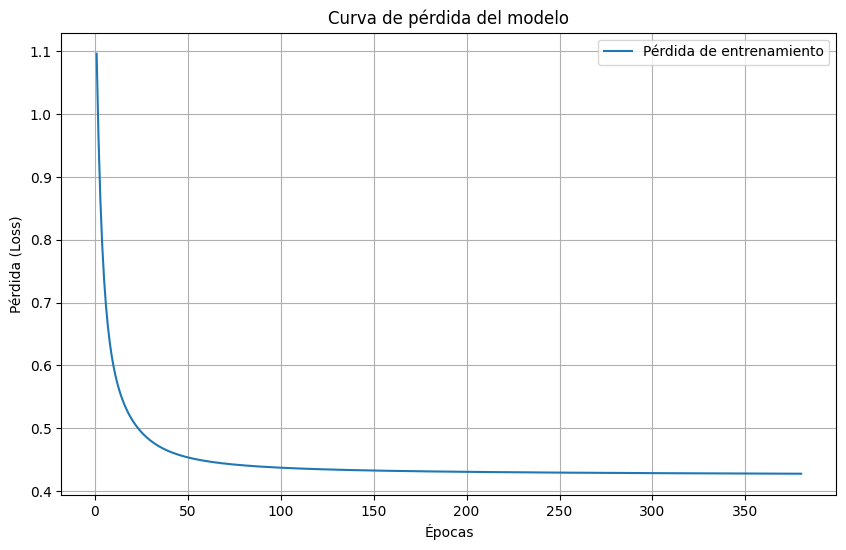

In [104]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), l, label='Pérdida de entrenamiento')
plt.title('Curva de pérdida del modelo')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (Loss)')
plt.legend()
plt.grid(True)
plt.show()

# **OPTIMIZADORES Y FUNCIONES DE PERDIDA**

In [105]:
D_in, H, D_out = 21, 64, 3

model = torch.nn.Sequential(
    torch.nn.Linear(D_in, H),
    torch.nn.ReLU(),
    torch.nn.Linear(H, D_out),
)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.8)

epochs = 450
log_each = 10
l = []
model.train()
for e in range(1, epochs+1):

    # forward
    y_pred = model(t_X_train)

    # loss
    loss = criterion(y_pred, t_y_train)
    l.append(loss.item())

    # ponemos a cero los gradientes
    optimizer.zero_grad()

    # Backprop (calculamos todos los gradientes automáticamente)
    loss.backward()

    # update de los pesos
    optimizer.step()

    if not e % log_each:
        print(f"Epoch {e}/{epochs} Loss {np.mean(l):.5f}")

y_pred = evaluate(torch.from_numpy(X_test_scaled).float().to("cpu"))
accuracy_score(y_test, y_pred.cpu().numpy())

Epoch 10/450 Loss 0.52182
Epoch 20/450 Loss 0.47728
Epoch 30/450 Loss 0.46133
Epoch 40/450 Loss 0.45296
Epoch 50/450 Loss 0.44775
Epoch 60/450 Loss 0.44416
Epoch 70/450 Loss 0.44152
Epoch 80/450 Loss 0.43949
Epoch 90/450 Loss 0.43787
Epoch 100/450 Loss 0.43654
Epoch 110/450 Loss 0.43543
Epoch 120/450 Loss 0.43448
Epoch 130/450 Loss 0.43366
Epoch 140/450 Loss 0.43294
Epoch 150/450 Loss 0.43231
Epoch 160/450 Loss 0.43174
Epoch 170/450 Loss 0.43123
Epoch 180/450 Loss 0.43077
Epoch 190/450 Loss 0.43035
Epoch 200/450 Loss 0.42997
Epoch 210/450 Loss 0.42962
Epoch 220/450 Loss 0.42929
Epoch 230/450 Loss 0.42899
Epoch 240/450 Loss 0.42871
Epoch 250/450 Loss 0.42844
Epoch 260/450 Loss 0.42820
Epoch 270/450 Loss 0.42797
Epoch 280/450 Loss 0.42775
Epoch 290/450 Loss 0.42754
Epoch 300/450 Loss 0.42735
Epoch 310/450 Loss 0.42717
Epoch 320/450 Loss 0.42699
Epoch 330/450 Loss 0.42683
Epoch 340/450 Loss 0.42667
Epoch 350/450 Loss 0.42652
Epoch 360/450 Loss 0.42638
Epoch 370/450 Loss 0.42624
Epoch 380/

0.8415052034859125

Podemos verificar que en ambos modelos conseguimos un 84% de precision.

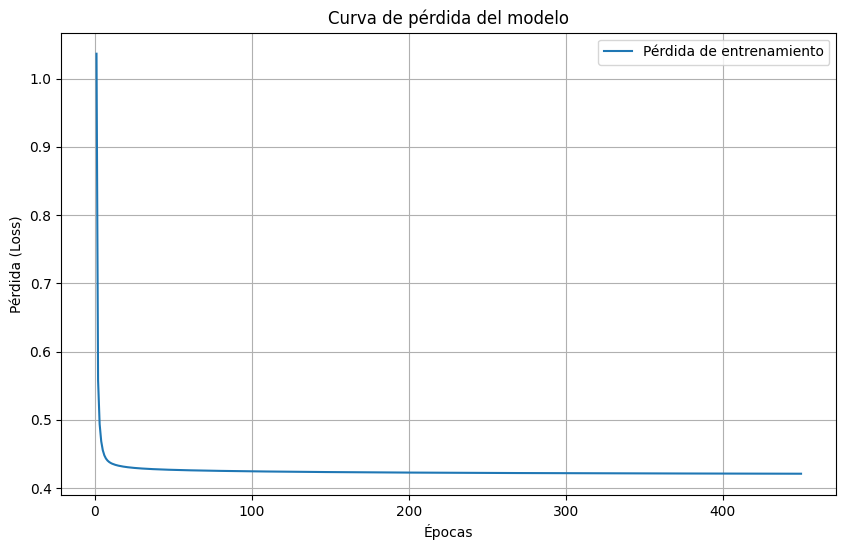

In [106]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), l, label='Pérdida de entrenamiento')
plt.title('Curva de pérdida del modelo')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (Loss)')
plt.legend()
plt.grid(True)
plt.show()